In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

In [3]:
(x_train,y_train),(x_test,y_test)=fashion_mnistmnist.load_data()
x_train=x_train
x_test=x_test
y_train= to_categorical(y_train)
y_test= to_categorical(y_test)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax'),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
model.fit(x_train, y_train, epochs=15, batch_size=32, validation_split=0.1)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6951 - loss: 5.8635 - val_accuracy: 0.7742 - val_loss: 0.7167
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7964 - loss: 0.6440 - val_accuracy: 0.7753 - val_loss: 0.6012
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8137 - loss: 0.5368 - val_accuracy: 0.8260 - val_loss: 0.5075
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8297 - loss: 0.4901 - val_accuracy: 0.8000 - val_loss: 0.5656
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8377 - loss: 0.4709 - val_accuracy: 0.8400 - val_loss: 0.4671
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8522 - loss: 0.4291 - val_accuracy: 0.8272 - val_loss: 0.5008
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8535 - loss: 0.4153 - val_accuracy: 0.8488 - val_loss: 0.4357
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8628 - loss: 0.3891

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8592 - loss: 0.4297
Test Accuracy: 0.86


In [24]:
import numpy as np

i = 10 # You can change this to test different images
img = x_test[i]  # Shape: (28, 28)

# Reshape to match model input: (1, 28, 28)
img_reshaped = img.reshape(1, 28, 28)

# Predict
prediction = model.predict(img_reshaped)
predicted_class = np.argmax(prediction)

print("Predicted class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted class: 4


Predicted Label: Coat


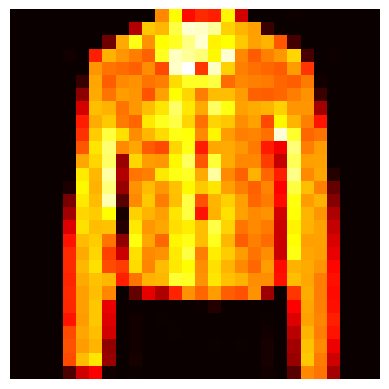

In [27]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"Predicted Label: {class_names[predicted_class]}")

import matplotlib.pyplot as plt

plt.imshow(img, cmap='hot')

plt.axis('off')
plt.show()
